In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [57]:
data=pd.read_csv('C:/a/run/fetch_california_housing.csv')
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [58]:
data.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [59]:
data_X = data['MedInc']
data_X = data['MedInc'].values.reshape(-1,1) 
data_Y=data['MedHouseVal']

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(data_X, data_Y, test_size=0.2, random_state=1)

In [61]:
reg=linear_model.LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
print(reg.coef_)

[0.42055457]


In [63]:
print(reg.intercept_)

0.4472183362106785


In [78]:
y_pred=reg.predict(X_test)
y_pred

array([1.8140207 , 1.27924351, 2.13498795, ..., 2.57017782, 2.49742188,
       1.58498668], shape=(4128,))

In [81]:
r2_score(y_test, y_pred)

0.47190835934467723

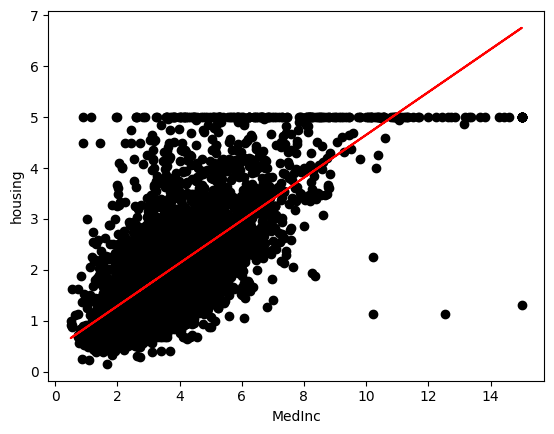

In [82]:
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test,y_pred, color='red')
plt.xlabel("MedInc")
plt.ylabel('housing')
plt.show()

In [83]:
# 다중선형회귀
data_Y=data['MedHouseVal']
data_X = data.drop(['MedHouseVal', 'Latitude', 'Longitude'], axis=1)

In [84]:
scaler=StandardScaler()
f_scaled=scaler.fit_transform(data_X)
f_scaled=pd.DataFrame(f_scaled, columns=data_X.columns)
f_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616
...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225


In [85]:
X_train, X_test, y_train, y_test=train_test_split(data_X, data_Y, test_size=0.2, random_state=1)
reg=linear_model.LinearRegression()
reg.fit(X_train, y_train)
y_pred=reg.predict(X_test)

In [89]:
r2_score(y_test, y_pred)

0.533257512867769

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
4712,3.2500,39.0,4.503205,1.073718,1109.0,1.777244
2151,1.9784,37.0,4.988584,1.038813,1143.0,2.609589
15927,4.0132,46.0,4.480296,1.012315,1534.0,3.778325
82,1.5208,52.0,3.908046,1.114943,200.0,2.298851
8161,5.1795,37.0,5.406360,1.024735,711.0,2.512367
...,...,...,...,...,...,...
2319,2.3173,25.0,4.915289,1.115702,1482.0,3.061983
5341,2.1875,49.0,4.571429,1.000000,14.0,2.000000
16888,5.0480,26.0,5.000000,1.000000,11.0,3.666667
6823,4.8750,42.0,5.347985,1.058608,829.0,3.036630


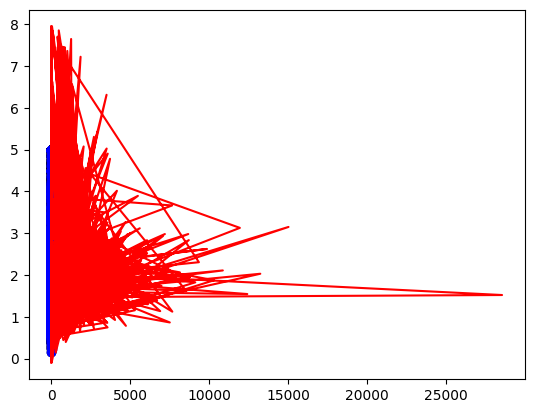

In [100]:
#중간 소득이 집값을 결정하는 강력한 변수임 -> 다른 변수 추가해도 중간 소득만 준 결정계수와 값이 거의 변함없음

plt.scatter(X_test['MedInc'], y_test, color='black')
plt.scatter(X_test['HouseAge'], y_test, color='blue')
plt.plot(X_test,y_pred, color='red')
X_test